<a href="https://colab.research.google.com/github/AnzorGozalishvili/IOAI-2025-lectures/blob/main/lecture_31_transformers_finetuning_on_classification/notebooks/Sklearn_Baseline_Arseniy_Sandalov_Georgian_Sentiment_Analysis_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sklearn Baseline (Pycaret)
- Sentiment Dataset Source: https://data.jrc.ec.europa.eu/dataset/9f04066a-8cc0-4669-99b4-f1f0627fdbbf
- dataset on huggingface: https://huggingface.co/datasets/Arseniy-Sandalov/Georgian-Sentiment-Analysis

### class label map
- https://huggingface.co/Arseniy-Sandalov/GeorgianBert-Sent/blob/main/config.json

```json
{
  "0": "Mixed",
  "1": "Positive",
  "2": "Neutral",
  "3": "Negative"
}
```

# Load Sentiment Dataset

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset
import pandas as pd

CLASSES = ['Mixed', 'Positive', 'Neutral', 'Negative']

dataset = load_dataset("Arseniy-Sandalov/Georgian-Sentiment-Analysis")
pd.Series(dataset['train']['sentiment']).value_counts()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,count
Neutral,1731
Negative,1417
Positive,765
Mixed,306


## Create Dataset Splits (check class distributions)

We use 80:10:10 splitting portions: https://huggingface.co/Arseniy-Sandalov/GeorgianBert-Sent#%F0%9F%93%8A-training-details

In [ ]:
from datasets import DatasetDict

# Assuming 'dataset' is your loaded dataset from the previous code
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)
dataset['validation'] = dataset.pop('test')
dataset['test'] = dataset['validation'].train_test_split(test_size=0.5, seed=42)['test']
dataset = DatasetDict(dataset)

# Verify the splits
print(dataset)
print(dataset['train'].features)
print(dataset['validation'].features)
print(dataset['test'].features)

# Check class distributions after splitting
print(pd.Series(dataset['train']['sentiment']).value_counts())
print(pd.Series(dataset['validation']['sentiment']).value_counts())
print(pd.Series(dataset['test']['sentiment']).value_counts())


DatasetDict({
    train: Dataset({
        features: ['text', 'sentiment', 'perturbation'],
        num_rows: 3375
    })
    validation: Dataset({
        features: ['text', 'sentiment', 'perturbation'],
        num_rows: 844
    })
    test: Dataset({
        features: ['text', 'sentiment', 'perturbation'],
        num_rows: 422
    })
})
{'text': Value(dtype='string', id=None), 'sentiment': Value(dtype='string', id=None), 'perturbation': Value(dtype='float64', id=None)}
{'text': Value(dtype='string', id=None), 'sentiment': Value(dtype='string', id=None), 'perturbation': Value(dtype='float64', id=None)}
{'text': Value(dtype='string', id=None), 'sentiment': Value(dtype='string', id=None), 'perturbation': Value(dtype='float64', id=None)}
Neutral     1374
Negative    1137
Positive     617
Mixed        247
Name: count, dtype: int64
Neutral     357
Negative    280
Positive    148
Mixed        59
Name: count, dtype: int64
Neutral     189
Negative    141
Positive     65
Mixed        27
Name

## Convert into Pandas Dataframes (For Pycaret)

In [ ]:
train_df = pd.DataFrame(dataset['train'])
validation_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])
train_df.shape, validation_df.shape, test_df.shape, train_df.head()

((3375, 3),
 (844, 3),
 (422, 3),
                                                 text sentiment perturbation
 0  თუ სპეციალისტებს დავუჯერებთ მდინარე ვერე თბილი...   Neutral         None
 1  ამ ფაქტს მოყვა მთავრობის კანცელარიის წინ დაუგე...  Negative         None
 2  არ ვფიქრობ, რომ ეს იყო საუკეთესო გადაწყვეტილებ...  Negative         None
 3  წითელი ღვინის სასარგებლო თვისებები მეცნიერების...  Positive         None
 4  განხილვის მთავარი საკითხები რეგიონში უსაფრთხოე...   Neutral         None)

# Train with Pycaret

In [ ]:
!pip install pycaret

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Georgian Stopwords Source (https://raw.githubusercontent.com/voku/stop-words/master/src/voku/helper/stopwords/ka.php)
GEORGIAN_STOPWORDS = [
    'ა.შ.', 'აგერ', 'აგრეთვე', 'ალბათ', 'ამაზე', 'ამას', 'ამასთან', 'ამასთანავე', 'ამგვარად', 'ამდენად', 'ამით', 'ამის',
    'ამისთვის',
    'ამიტომ', 'ამიტომაც', 'ამჟამად', 'ამჯერად', 'ან', 'ანუ', 'არ', 'არა', 'არადა', 'არათუ', 'არამარტო', 'არამედ',
    'არამხოლოდ',
    'არანაკლებ', 'არასოდეს', 'არაუადრეს', 'არაუგვიანეს', 'არაუმეტეს', 'არსად', 'არსაიდან', 'არც', 'არცერთ', 'ასევე',
    'ასეც',
    'აქამდე', 'აღარ', 'აღარც', 'ბოლოს', 'ბოლოსკენ', 'გამო', 'გამუდმებით', 'განსაკუთრებით', 'გარდა', 'გარეშე', 'და',
    'დასასრულს',
    'დასაწყისში', 'დროულად', 'ე.ი.', 'ე.წ.', 'ეგებ', 'ერთადერთი', 'ერთადერთმა', 'ერთ-ერთი', 'ერთხელ', 'ესოდე', 'ვერ',
    'ვითომ',
    'ვინაიდან', 'ვინძლო', 'ვისაც', 'ზემოაღნიშნულმა', 'ზოგჯერ', 'თავად', 'თავადაც', 'თავადვე', 'თავდაპირველად',
    'თავიდანვე',
    'თავის მხრივ', 'თან', 'თანაც', 'თანახმადაც', 'თანდათან', 'თვით', 'თვითონ', 'თვითონაც', 'თვითონვე', 'თითოეულმა',
    'თითქოს',
    'თუ', 'თუკი', 'თუმცა', 'თუმცაღა', 'თუნდაც', 'იმავდროულად', 'იმავე', 'იმან', 'იმას', 'იმდენად', 'იმთავითვე', 'იმით',
    'იმის',
    'იმისთვის', 'იმიტომ', 'ისევე', 'ისეთი', 'ისეც', 'იშვიათად', 'კერძოდ', 'კვლავ', 'კი', 'კიდევ', 'მაგალითად', 'მაგან',
    'მაგას',
    'მაგით', 'მაგის', 'მაგრამ', 'მათი', 'მაინც', 'მანამ', 'მანამდე', 'მართალია', 'მარტო', 'მაშასადამე', 'მაშინ',
    'მაშინვე', 'მერე',
    'მეტად', 'მთელი', 'მიერ', 'მით', 'მიმართ', 'მისივე', 'მსგავსი', 'მხოლოდ', 'ნაწილობრივ', 'ნეტავ', 'ნეტავი', 'ნუ',
    'ნურასოდეს',
    'ნურც', 'ნუღარ', 'ნუღარც', 'ოდენ', 'ოდესღაც', 'ოღონდ', 'პირველი', 'პირიქით', 'პრინციპში', 'რადგან', 'რადგანაც',
    'რათა', 'რაკი',
    'რამდენად', 'რამდენადაც', 'რამეთუ', 'რამენაირად', 'რამეფრად', 'რანაირადაც', 'რასაკვირველია', 'რასაც', 'რაღაც',
    'რაც', 'რითაც',
    'რისთვისაც', 'როგორადაც', 'როგორიც', 'როგორიცაა', 'როგორღაც', 'როგორც', 'როდესაც', 'როდესღაც', 'რომ', 'რომელიმე',
    'რომელიც',
    'რომელსაც', 'რომლებიც', 'რომლითაც', 'რომლის', 'როცა', 'საბოლოოდ', 'სადაც', 'სადღაც', 'საერთოდ', 'სათანადოდ',
    'საიდანაც',
    'სამომავლოდ', 'სანამ', 'სანამდე', 'სრულად', 'სულ', 'სწორედ', 'სხვადასხვა', 'სხვები', 'უკვე', 'უნდა', 'უსათუოდ',
    'უფრო', 'უცებ',
    'უცნაურად', 'ფაქტობრივად', 'ყველა', 'ყოველგვარი', 'ყოველთვის', 'ყოველი', 'ყოველივე', 'შედარებით', 'შედეგად',
    'შემდგომ',
    'შემდგომში', 'შემდეგ', 'შესახებ', 'შორის', 'ჩვეულებრივ', 'წინააღმდეგ', 'წინაშე', 'ხან', 'ხოლმე', 'ხოლო', 'ხშირად',
    'ჯერაც',
    'ჯერჯერობით',
    'ამის გარდა', 'ამის გარეშე', 'ამის მიუხედავად', 'ამასთან ერთად', 'ამის მიხედვით', 'ამის ნაცვლად', 'ამის პასუხად',
    'ამასთან შედარებით', 'ამბობს, რომ', 'ამ დროს', 'ამ თემაზე', 'ამ მიზნით', 'ამის საპირისპიროდ', 'ამის გამო',
    'ამ მხრივ',
    'ამის უარსაყოფად', 'ამის შედეგად', 'ამ შემთხვევაში', 'ამავე დროს', 'ამას გარდა', 'ამასთან დაკავშირებით',
    'ამის შემდეგ',
    'ამის შესაბამისად', 'ამის შესახებ', 'ამისგან განსხვავებით', 'არა მარტო', 'არა მხოლოდ', 'არა უადრეს', 'არა უგვიანეს',
    'არც ერთი', 'არც კი', 'არც მეორე', 'ასე ვთქვათ', 'ასე მაგალითად', 'ასე რომ', 'ასე შემდეგ', 'ასევე განიხილავს',
    'აქედან გამომდინარე', 'აქედან დასკვნა', 'აღნიშნა რომ', 'აღნიშნულთან დაკავშირებით', 'აცხადებს რომ', 'ბოლო ერთი',
    'ბოლო პერიოდში', 'ბოლო წლებში', 'გამოთქვა იმედი', 'განაცხადა, რომ', 'განმარტა, რომ', 'გარდა ამისა',
    'გარშემო არსებული',
    'და სხვ.', 'და სხვა', 'დაადასტურა, რომ', 'ეგრეთ წოდებული', 'ეგრეთ წოდებულმა', 'ერთი თვალსაზრისით', 'ერთი მხრივ',
    'ერთის მხრივ', 'ეს კი', 'ესე იგი', 'ვიდრე არ', 'თავიდან ბოლომდე', 'თუ რამდენად', 'თუ როგორ', 'იგივეა რაც',
    'იმ შემთხვევაში', 'იმაზე მეტი', 'იმაზე, რომ', 'იმას, რომ', 'იმასთან დაკავშირებით', 'იმდენად რამდენადაც',
    'იმედი გამოთქვა', 'იმის გამო', 'იმის თაობაზე', 'იმის საწინააღმდეგოდ', 'იმისათვის, რომ', 'იმისთვის, რათა',
    'იმისთვის, რომ',
    'იმიტომ, რომ', 'ის, რომელიც', 'ისე როგორც', 'ისე, რომ', 'ისევე როგორც', 'ისეთი როგორიც', 'იქიდან გამომდინარე',
    'კიდევ ერთხელ', 'მაგრამ თუ', 'მათ შორის', 'მათი ვარაუდით', 'მანამ, სანამ', 'მას შემდეგ', 'მაშინ, როცა',
    'მაშინაც კი',
    'მეორე მხრივ', 'მეორეც ერთი', 'მერე მეორე', 'მით უფრო', 'მიიჩნევს, რომ', 'მისი განმარტებით', 'მისი თქმით',
    'მისივე თქმით', 'მიუხედავად ამისა', 'ნურც კი', 'პირველ რიგში', 'რა დროსაც', 'რა მიზეზითაც', 'რაც შეეხება',
    'რაც შეიძლება', 'რის გამოც', 'რის საფუძველზედაც', 'რის საფუძველზეც', 'რის შედეგადაც', 'რის შემდეგაც', 'როგორც კი',
    'რომ არა', 'რომ თუ', 'რომელთა გამოც', 'რომლის თანახმად', 'რომლის თანახმადაც', 'რომლის მიხედვითაც', 'რომლის შესახებ',
    'საკითხთან დაკავშირებით', 'სულ მცირე', 'სულ ცოტა', 'სხვა კუთხით', 'სხვა მხრივ', 'სხვა რამ', 'სხვათა შორის',
    'უფრო მეტიც',
    'ყოველივე ეს', 'შემდეგ უკვე', 'ჩვენი განცხადებით', 'ჯერ ერთი', 'ჯერ კიდევ', 'ამ ბოლო დროს', 'ამა თუ იმ',
    'ასე თუ ისე',
    'აქედან ჩანს, რომ', 'ბოლოს და ბოლოს', 'გამომდინარე იქიდან, რომ', 'და ასე შემდეგ', 'ვინაიდან და რადგანაც',
    'თუ რის საფუძველზე', 'იმის გათვალისწინებით, რომ', 'იმის გამო, რომ', 'იმის ნაცვლად, რომ', 'ისევ და ისევ',
    'იქვე აღნიშნა, რომ', 'იქიდან გამომდინარე, რომ', 'კიდევ და კიდევ', 'მაინც და მაინც', 'მას შემდეგ, რაც',
    'მიუხედავად იმისა, თუ', 'მიუხედავად იმისა, რომ', 'როგორც უკვე ითქვა', 'როდის და რატომ', 'უფრო და უფრო',
]

In [ ]:
#import data and preprocess
import pandas as pd
import re
import string
from string import punctuation

#feature extraction
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
sentiment_map = {k:idx for idx, k in enumerate(CLASSES)}

## TF-IDF Vectorizer Features

In [ ]:
train_valid_df = pd.concat([train_df, validation_df], axis=0).reset_index(drop=True)

In [ ]:
tv = TfidfVectorizer(lowercase = True, stop_words = GEORGIAN_STOPWORDS, token_pattern="[A-Za-zა-ჰ]+")
tf_idf_df = tv.fit_transform(train_valid_df['text'])
tf_idf_df = pd.DataFrame(tf_idf_df.toarray(), columns=tv.get_feature_names_out())
tf_idf_df['sentiment'] = train_valid_df.reset_index().sentiment.map(sentiment_map)
tf_idf_df

,act,allwine,bbc,benz,biletebi,c,caesars,charlie,co,cola,...,ჰქონოდა,ჰქონოდათ,ჰყავდათ,ჰყავთ,ჰყავს,ჰყვება,ჰყვებიან,ჰყოლია,ჰყოფნიდათ,sentiment
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4215,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4216,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


In [ ]:
test_tf_idf_df = tv.transform(test_df['text'])
test_tf_idf_df = pd.DataFrame(test_tf_idf_df.toarray(), columns=tv.get_feature_names_out())
test_tf_idf_df['sentiment'] = test_df.reset_index().sentiment.map(sentiment_map)
test_tf_idf_df.index = test_tf_idf_df.index + tf_idf_df.shape[0]
test_tf_idf_df

,act,allwine,bbc,benz,biletebi,c,caesars,charlie,co,cola,...,ჰქონოდა,ჰქონოდათ,ჰყავდათ,ჰყავთ,ჰყავს,ჰყვება,ჰყვებიან,ჰყოლია,ჰყოფნიდათ,sentiment
4219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4220,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4223,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4636,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4637,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4638,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4639,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
from pycaret.classification import *
# NOTE: 88% because we split that already by 80/10/10 for train/valid/test and we need to have 80/90 fraction which is close to 0.88
setup = setup(data=tf_idf_df, target='sentiment', session_id=123, train_size = 0.88, fold=5, test_data=test_tf_idf_df)

,Description,Value
0,Session id,123
1,Target,sentiment
2,Target type,Multiclass
3,Original data shape,"(4641, 15258)"
4,Transformed data shape,"(4641, 15258)"
5,Transformed train set shape,"(4219, 15258)"
6,Transformed test set shape,"(422, 15258)"
7,Numeric features,15257
8,Preprocess,True
9,Imputation type,simple


In [26]:
models = compare_models()

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,10:27:42
Status,. . . . . . . . . . . . . . . . . .,Fitting 5 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Gradient Boosting Classifier


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.5729,0.0000,0.5729,0.5564,0.5481,0.3363,0.3440,10.0440
svm,SVM - Linear Kernel,0.5599,0.0000,0.5599,0.5381,0.5436,0.3290,0.3320,18.2420
lr,Logistic Regression,0.5568,0.0000,0.5568,0.5449,0.5183,0.2944,0.3124,19.0380
knn,K Neighbors Classifier,0.5231,0.7051,0.5231,0.5129,0.5077,0.2759,0.2827,13.9880
nb,Naive Bayes,0.5108,0.6362,0.5108,0.5025,0.5037,0.2707,0.2720,7.5260
rf,Random Forest Classifier,0.5072,0.6924,0.5072,0.5059,0.4633,0.2117,0.2382,24.6600
dt,Decision Tree Classifier,0.4641,0.5904,0.4641,0.4459,0.4493,0.1839,0.1866,23.6160
ada,Ada Boost Classifier,0.4380,0.0000,0.4380,0.4264,0.3541,0.0979,0.1316,16.6580
qda,Quadratic Discriminant Analysis,0.1804,0.0000,0.1804,0.1355,0.1471,-0.0292,-0.0348,45.2920


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

KeyboardInterrupt: 

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5604,0.0000,0.5604,0.5648,0.5354,0.3142,0.3221
1,0.5604,0.0000,0.5604,0.5339,0.5373,0.3186,0.3246
2,0.5770,0.0000,0.5770,0.5602,0.5526,0.3468,0.3521
3,0.5948,0.0000,0.5948,0.5680,0.5676,0.3694,0.3792
4,0.5718,0.0000,0.5718,0.5550,0.5476,0.3325,0.3422
Mean,0.5729,0.0000,0.5729,0.5564,0.5481,0.3363,0.3440
Std,0.0127,0.0000,0.0127,0.0121,0.0116,0.0201,0.0208


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

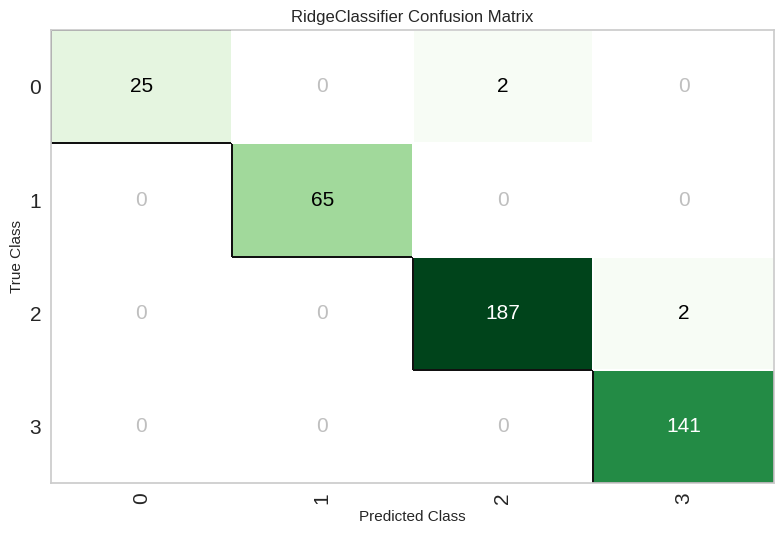

In [31]:
ridge = create_model('ridge')
plot_model(ridge, "confusion_matrix")

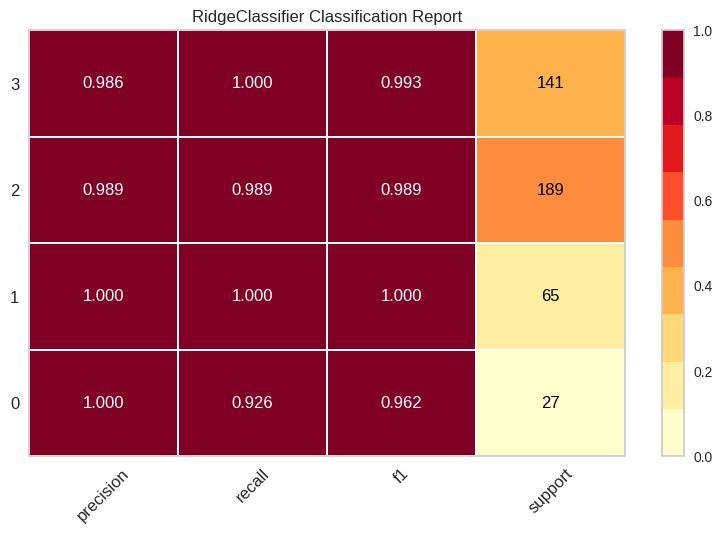

In [33]:
plot_model(ridge, plot='class_report')
report = pull()

In [34]:
test_preds_df = predict_model(ridge, data=test_tf_idf_df)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.9905,0,0.9905,0.9906,0.9904,0.9856,0.9856


In [35]:
test_preds_df.head()

,act,allwine,bbc,benz,biletebi,c,caesars,charlie,co,cola,conflict,david,days,deursche,ebrd,ebrdის,euobserver,f,facebook,facebookით,facebookის,fashion,festival,fiuczynski,flex,fresh,frontera,fronteraს,gds,geს,ggu,glass,google,guardian,gwp,hennessy,idfi,ii,iri,jazz,je,jetbird,l,loudspeakers,lufthansa,m,mercedes,microjam,mixed,nato,ndi,neutral,news,opel,p,pace,palace,pisa,planet,rc,s,suis,take,tbilisi,that,the,tv,usaid,video,volnovakha,welle,x,xo,zone,ა,აალაპარაკა,აამოქმედონ,ააფეთქეს,ააშკარავებს,აბანოთუბანში,აბარებდნენ,აბასს,აბაშიშვილის,აბაშიშვილმა,აბაშიშივილის,აბაშიძე,აბაშიძემ,აბაშიძეც,აბაშიძის,აბესაძე,აბესაძემ,აბესაძეს,აბინძურებენ,აბონენტის,აბორტი,აბრა,აბრეშუმის,აბსოლიტურად,აბსოლუტურად,აბსურდი,აბულაძე,აბულაძემ,აბულაძეს,აგარაკების,აგდებული,აგებს,აგენტზე,აგენტი,აგვარებს,აგვისტოდან,აგვისტოს,აგვისტოსთან,აგო,აგოს,აგრამუნტმა,აგრარულ,აგრესია,აგრესიას,აგრესიის,აგრესიულ,აგრესიული,აგრესიულია,აგროვებს,აგროპროექტის,აგრძელებენ,აგრძელებს,აგულაშვილთან,აგულაშვილი,აგულაშვილის,აგულაშვილმა,აგულაშვილს,აგური,ადამ,ადამიანებზე,ადამიანებთან,ადამიანები,ადამიანებით,ადამიანების,ადამიანებისთვის,ადამიანებს,ადამიანზე,ადამიანთა,ადამიანთან,ადამიანი,ადამიანია,ადამიანის,ადამიანისგან,ადამიანისთვის,ადამიანმა,ადამიანს,ადამიანურ,ადამიანური,ადამინები,ადანაშაულებდა,ადანაშაულებდნენ,ადანაშაულებენ,ადანაშაულებს,ადაპტირებული,ადარებს,ადასტურებენ,ადასტურებს,ადგენს,ადგილას,ადგილების,ადგილებს,ადგილებში,ადგილზე,ადგილზევე,ადგილთან,ადგილი,ადგილია,ადგილიან,ადგილიდან,ადგილის,ადგილობრივ,ადგილობრივები,ადგილობრივების,ადგილობრივებმა,ადგილობრივი,ადგილობრივმა,ადგილს,ადგილსამყოფელი,ადგილსამყოფელის,ადევნებდა,ადეიშვილზე,ადეიშვილის,ადეიშვილს,ადეკვატურ,ადეკვატურად,ადეკვატური,ადვილად,ადვილი,ადვოკატ,ადვოკატები,ადვოკატების,ადვოკატებს,ადვოკატი,ადვოკატის,ადვოკატმა,ადიგენის,ადიდა,ადიდდა,ადიდების,ადიდებულმა,ადმინისტრაცია,ადმინისტრაციაზე,ადმინისტრაციამ,ადმინისტრაციასთან,ადმინისტრაციაში,ადმინისტრაციის,ადმინისტრაციულ,ადმინისტრაციული,ადმინიტრაციას,ადრე,ადრესატებს,ადრესატი,ადრესატია,ადრეულ,აედევნა,აეკრძალათ,აენთო,აეროპორტებში,აეროპორტის,აეროპორტში,აეღო,ავადმყოფი,ავადმყოფობის,ავადმყოფს,ავალდებულებთ,ავალდებულებს,ავარია,ავარიაში,ავარიის,ავარიისას,ავარიულია,ავაქსის,ავაშენებთ,ავერსმა,ავთანდილ,ავია,ავიაგამანადგურებლების,ავიაკატასტროფის,ავიაკომპანია,ავიაკომპანიის,ავიამიმოსვლის,ავიარეისები,ავიაციამ,ავიაციას,ავიაწვრთნა,ავიდა,...,ხელყოფს,ხელყუმბარა,ხელშეკრულება,ხელშეკრულებამდე,ხელშეკრულებას,ხელშეკრულებაში,ხელშეკრულებები,ხელშეკრულებების,ხელშეკრულების,ხელშეკრულებისა,ხელშეუხებლობის,ხელშეწყობასა,ხელშეწყობით,ხელშეწყობის,ხელში,ხეობა,ხეობას,ხეობაში,ხეობიდან,ხეობის,ხერხეულიძემ,ხეჩიკაშვილი,ხვალ,ხვალიდან,ხვალინდელ,ხვალინდელი,ხვდება,ხვდებიან,ხვდებოდეს,ხიდამდე,ხიდაშელთან,ხიდაშელი,ხიდაშელის,ხიდაშელისა,ხიდაშელისთვის,ხიდაშელმა,ხიდაშელს,ხიდთან,ხიდი,ხიდის,ხილვა,ხილის,ხისგან,ხიტირი,ხმა,ხმათა,ხმალაძე,ხმალაძემ,ხმალაძის,ხმამაღლა,ხმაურზე,ხმაური,ხმაურია,ხმაურიან,ხმაურით,ხმაურის,ხმები,ხმების,ხმებს,ხმელთაშუა,ხმიდან,ხმით,ხმის,ხნით,ხნის,ხო,ხობის,ხოკრიშვილზე,ხოკრიშვილმა,ხომ,ხომალდი,ხომალდს,ხომერიკმა,ხონის,ხონში,ხორვატ,ხორვატია,ხორვატიის,ხორციელდება,ხოშტარია,ხოშტარიამ,ხოშტარიას,ხოშტარიასადმი,ხსენების,ხსენებული,ხსნიან,ხსნის,ხსოვნას,ხუთეულის,ხუთი,ხუთსაათიანი,ხუთშაბათს,ხულიგნობის,ხუმრობით,ხუნდაძე,ხუშტურებს,ხუშტურის,ხუციშვილმა,ხშირ,ხშირი,ხშირია,ჯაბა,ჯადოსნური,ჯავად,ჯავახეთის,ჯავახიშვილი,ჯავახიშვილის,ჯამლეტ,ჯამური,ჯამში,ჯანდაცვასა,ჯანდაცვის,ჯანელიძე,ჯანელიძეს,ჯანელიძეც,ჯანელიძის,ჯანი,ჯანიშვილი,ჯანმრთელობა,ჯანმრთელობაზე,ჯანმრთელობის,ჯანმრთელობისა,ჯანსაღ,ჯანსაღი,ჯანყარაშვილი,ჯართის,ჯარიმა,ჯარიმაა,ჯარიმის,ჯარისკაცებზე,ჯარისკაცების,ჯარისკაცი,ჯარისკაცის,ჯარს,ჯაფარიძე,ჯაფარიძეა,ჯაფარიძემ,ჯაფარიძის,ჯაშუშის,ჯაჭვებითაა,ჯაჭვების,ჯაჰანგირის,ჯგუფები,ჯგუფების,ჯგუფებმა,ჯგუფებს,ჯგუფთან,ჯგუფი,ჯგუფის,ჯგუფისა,ჯგუფს,ჯგუფსა,ჯგუფუთან,ჯგუფურად,ჯგუფური,ჯგუფში,ჯდება,ჯემ,ჯემალ,ჯემის,ჯეოსტატის,ჯეოსტატში,ჯერ,ჯერობით,ჯერსიში,ჯვარედინი,ჯვარი,ჯვარსა,ჯვარცმა,ჯვარცმას,ჯვრიდან,ჯი,ჯიბუტია,ჯილდოს,ჯინო,ჯიპს,ჯიხურებში,ჯო,ჯოგლიძე,ჯოგლიძის,ჯოკია,ჯოლიძის,ჯონ,ჯონდი,ჯონსონისგან,ჯონსონს,ჯორჯ,ჯორჯიან,ჯოყოლო,ჰაბის,ჰაერზე,ჰაერიდან,ჰაერის,ჰაიდ,ჰაიდი,ჰაიკენს,ჰაილუქსი,ჰამქარის,ჰანი,ჰანის,ჰანმა,

In [39]:
from sklearn.metrics import f1_score
print(f1_score(test_preds_df['sentiment'], test_preds_df['prediction_label'], average='macro'))

0.9859785493588311
